In [1]:
import os
import json

import cv2
import numpy as np
from PIL import Image, ImageDraw

In [18]:
def augment_images(img_path, mask_bbox, loc_bbox, resolution, expand_ratio=0.1):
    """
    Crop và resize img về kích thước resolution, thay đổi tọa độ bbox tương ứng.
    Đảm bảo crop vào phần có mask_bbox và loc_bbox
    parameters:
        img_path: path to img
        mask_bbox, loc_bbox: (x1, y1, x2, y2) theo tọa độ ảnh gốc
    """
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Kích thước hình vuông crop
    square_size = min(h, w)
    half = square_size // 2

    # Hai bbox cần đảm bảo nằm trong crop
    bboxes = np.array([mask_bbox, loc_bbox])

    # Tìm min/max của toàn bộ vùng cần cover
    x_min = np.min(bboxes[:, 0])
    y_min = np.min(bboxes[:, 1])
    x_max = np.max(bboxes[:, 2])
    y_max = np.max(bboxes[:, 3])

    # Tâm ban đầu
    cx = (x_min + x_max)/2
    cy = (y_min + y_max)/2

    # Crop ban đầu
    crop_x1 = int(cx - half)
    crop_y1 = int(cy-half)
    crop_x2 = crop_x1 + square_size
    crop_y2 = crop_y1 + square_size

    # Hàm dịch crop vào trong ảnh
    def shift_into_image(x1, y1, x2, y2, W, H):
        dx1 = max(0, -x1)
        dy1 = max(0, -y1)
        dx2 = max(0, x2 - W)
        dy2 = max(0, y2 - H)
        return x1 + dx1 - dx2, y1 + dy1 - dy2, x2 + dx1 - dx2, y2 + dy1 - dy2

    crop_x1, crop_y1, crop_x2, crop_y2 = shift_into_image(
        crop_x1, crop_y1, crop_x2, crop_y2, w, h
    )

    # Kiểm tra đảm bảo chứa đủ bbox
    # for (bx1, by1, bx2, by2) in bboxes:
    #     if not (crop_x1 <= bx1 and bx2 <= crop_x2 and crop_y1 <= by1 and by2 <= crop_y2):
    #         logger.info(f"{img_path} Bbox quá to, không thể chứa trong crop hình vuông min(h,w).")

    # Crop
    crop = img[crop_y1:crop_y2, crop_x1:crop_x2]

    # Resize
    resized = cv2.resize(crop, (resolution, resolution))
    scale = resolution/square_size

    # Chuyển toạ độ bbox
    def convert_bbox(bbox):
        x1, y1, x2, y2 = bbox
        x1 = int((x1 - crop_x1) * scale)
        y1 = int((y1 - crop_y1) * scale)
        x2 = int((x2 - crop_x1) * scale)
        y2 = int((y2 - crop_y1) * scale)
        return [x1, y1, x2, y2]

    new_mask_bbox = convert_bbox(mask_bbox)
    new_loc_bbox = convert_bbox(loc_bbox)

    # Mở rộng bbox
    def expand_box(bbox, ratio, max_val):
        """
        Mở rộng bbox theo tỷ lệ ratio.
        Ví dụ: ratio=0.1 => Chiều rộng và cao tăng thêm 10%.
        """
        x1, y1, x2, y2 = bbox
        w_box = x2 - x1
        h_box = y2 - y1
        
        # Tính lượng cần mở rộng (padding mỗi bên là một nửa của phần tăng thêm)
        dw = int(w_box * ratio)
        dh = int(h_box * ratio)
        
        # Mở rộng từ tâm ra
        x1 = x1 - dw // 2
        y1 = y1 - dh // 2
        x2 = x2 + dw // 2
        y2 = y2 + dh // 2
        
        # Clip lại để không văng ra khỏi ảnh
        return [
            max(0, min(max_val, x1)),
            max(0, min(max_val, y1)),
            max(0, min(max_val, x2)),
            max(0, min(max_val, y2))
        ]
    
    # Thực hiện mở rộng bbox (trước khi tạo mask và norm)
    if expand_ratio > 0:
        new_mask_bbox = expand_box(new_mask_bbox, expand_ratio, resolution)
        new_loc_bbox = expand_box(new_loc_bbox, expand_ratio, resolution)
    else:
        # Nếu không expand thì vẫn cần clip lại cho an toàn
        new_mask_bbox = expand_box(new_mask_bbox, 0, resolution)
        new_loc_bbox = expand_box(new_loc_bbox, 0, resolution)

    
    # Tạo mask
    mask = np.zeros((resolution, resolution), dtype=np.uint8)
    x1, y1, x2, y2 = new_mask_bbox
    mask[y1:y2, x1:x2] = 255

    # Chuẩn hóa loc_bbox về [0,1]
    lx1, ly1, lx2, ly2 = new_loc_bbox
    new_loc_bbox_norm = [
        lx1 / resolution,
        ly1 / resolution,
        lx2 / resolution,
        ly2 / resolution
    ]

    return resized, mask, new_mask_bbox, new_loc_bbox_norm

In [19]:
data_root = '/mnt/disk2/hachi/data/'
out_root = '/home/hachi/obj-ins/PowerPaint/validation'
img_folders = ['train/3905_b3']

for img_folder in img_folders:
    img_path = os.path.join(data_root, img_folder, 'ground_truth.jpg')
    anno_path = os.path.join(data_root, img_folder, 'annotation.json')
    with open(anno_path, 'r') as f:
        anno = json.load(f)
    mask_bbox = anno['inpainted_bboxes'][0]
    loc_bbox = anno['inpainted_bboxes'][1]

    img, mask, mb, lb = augment_images(img_path, mask_bbox, loc_bbox, 512)
    img = Image.fromarray(img).convert('RGB')
    mask = Image.fromarray(mask).convert('L')

    # img_save_path = os.path.join(out_root, img_folder, 'ground_truth.png')
    # mask_save_path = os.path.join(out_root, img_folder, 'mask.png')
    # os.makedirs(os.path.dirname(img_save_path), exist_ok=True)
    # os.makedirs(os.path.dirname(mask_save_path), exist_ok=True)

    # img.save(img_save_path)
    # mask.save(mask_save_path)


In [14]:
mb, lb

([432, 200, 512, 294], [0.0, 0.75, 0.220703125, 0.99609375])

In [20]:
mb,lb

([428, 196, 512, 298], [0.0, 0.73828125, 0.232421875, 1.0])

In [16]:
img.size

(512, 512)

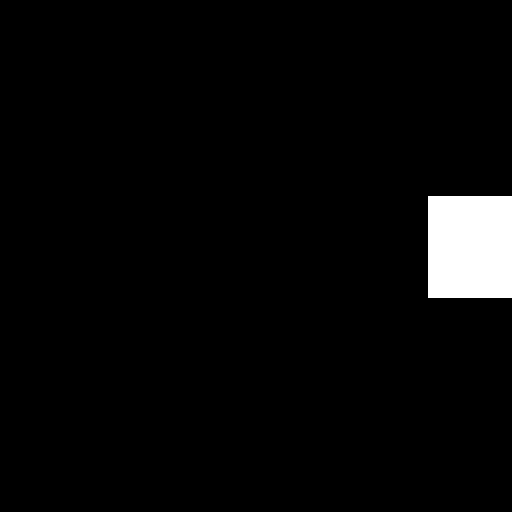

In [22]:
mask

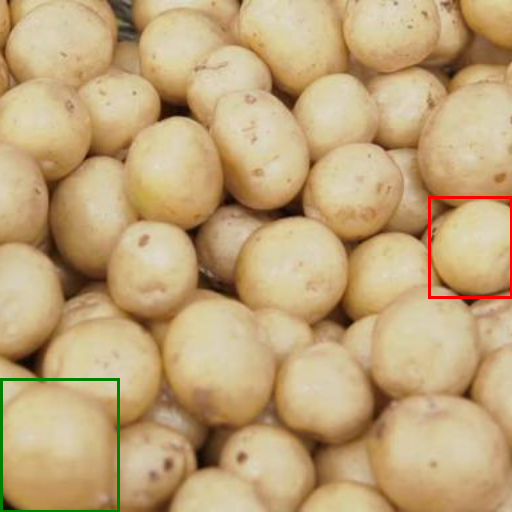

In [21]:
draw = ImageDraw.Draw(img)
x1,y1,x2,y2 = lb
h,w = img.size
draw.rectangle(mb, outline='red', width=3)
draw.rectangle([x1*w, y1*h, x2*w, y2*h], outline='green', width=3)
img

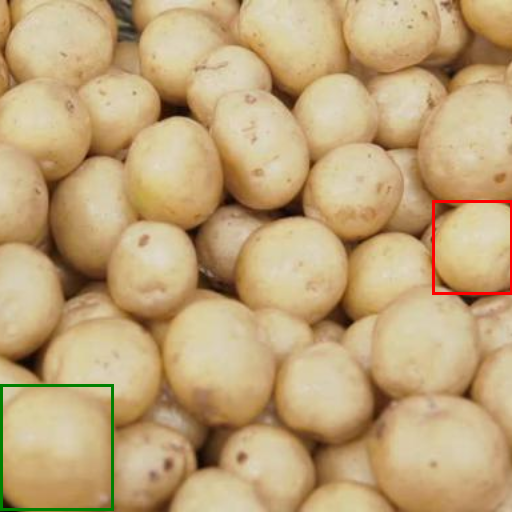

In [17]:
draw = ImageDraw.Draw(img)
x1,y1,x2,y2 = lb
h,w = img.size
draw.rectangle(mb, outline='red', width=3)
draw.rectangle([x1*w, y1*h, x2*w, y2*h], outline='green', width=3)
img

In [27]:
len(os.listdir('/workdir/radish/hachi/OBJ_INS/phase2_V2/train'))

4653

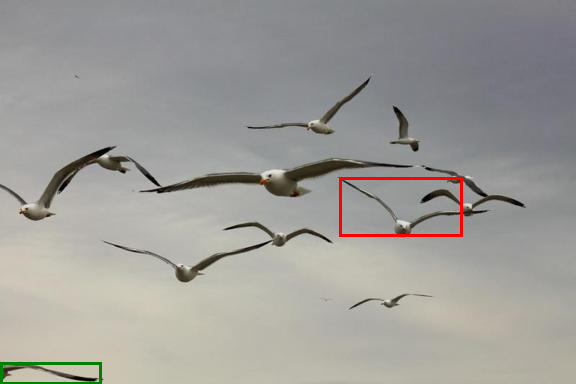

In [18]:
img1 = Image.open('/workdir/radish/hachi/OBJ_INS/phase2_V2/val/190_b1/ground_truth.jpg')
mb = [
      339,
      177,
      462,
      236
    ]
lb = [
      0,
      362,
      101,
      384
    ]

draw = ImageDraw.Draw(img1)
draw.rectangle(mb, outline='red', width=3)
draw.rectangle(lb, outline='green', width=3)
img1

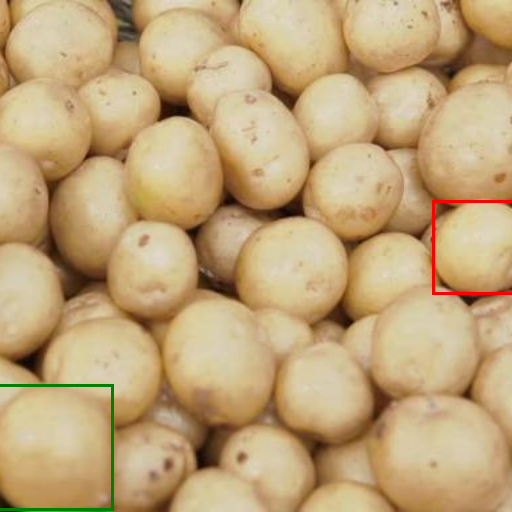

In [11]:
draw = ImageDraw.Draw(img)
draw.rectangle(mb, outline='red', width=3)
draw.rectangle(lb, outline='green', width=3)
img

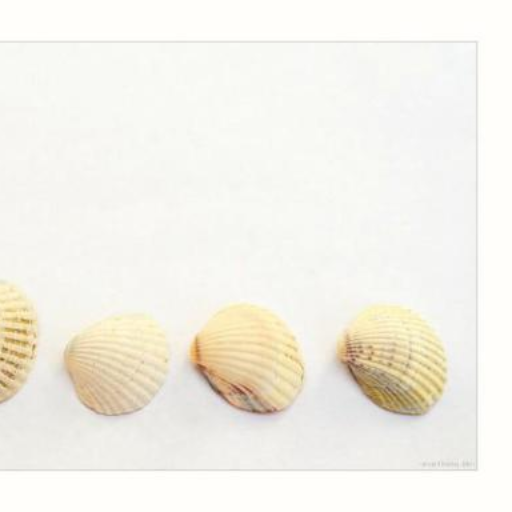

In [12]:
Image.open('/home/hachi/obj-ins/PowerPaint/validation/test/2_b1/ground_truth.png')

In [ ]:
from powerpaint.pipelines import StableDiffusionInpaintPipeline

In [ ]:

def log_validation(tokenizer, text_encoder, unet, args, accelerator, weight_dtype, step):

    pipe = StableDiffusionInpaintPipeline.from_pretrained(
        args.pretrained_model_name_or_path,
        text_encoder=accelerator.unwrap_model(text_encoder),
        tokenizer=tokenizer,
        unet=accelerator.unwrap_model(unet),
        safety_checker=None,
        revision=args.revision,
        variant=args.variant,
        torch_dtype=weight_dtype,
        local_files_only=True, # load files from local cache
    )
    pipe = pipe.to(accelerator.device)
    pipe.set_progress_bar_config(disable=True)


    # load validation images
    image_logs = []
    for case in args.validation_data.cases:
        validation_prompts = case.prompt
        validation_image = Image.open(os.path.join(args.validation_data.data_root, case.image)).convert("RGB")
        validation_mask = Image.open(os.path.join(args.validation_data.data_root, case.mask))
        validation_mask = validation_mask.resize((validation_image.size[0], validation_image.size[1]), Image.NEAREST)
        validation_mask = validation_mask.convert("L")
        hole_value = (0, 0, 0)
        validation_image = Image.composite(
            Image.new("RGB", (validation_image.size[0], validation_image.size[1]), hole_value),
            validation_image,
            validation_mask.convert("L"),
        )
        image_grid = Image.new(
            "RGB",
            (validation_image.size[0] * (1 + len(validation_prompts)), validation_image.size[1]),
            (255, 255, 255),
        )
        image_grid.paste(validation_image, (0, 0))
        for i, p in enumerate(validation_prompts):
            with torch.autocast(accelerator.device.type):
                image = pipe(
                    promptA=p.promptA,
                    promptB=p.promptB,
                    negative_promptA=p.get("negative_promptA", None),
                    negative_promptB=p.get("negative_promptB", None),
                    tradeoff=p.tradeoff,
                    image=validation_image,
                    mask=validation_mask,
                    num_inference_steps=45,
                ).images[0]
            image_logs.append(image)
            image_grid.paste(image, (validation_image.size[0] * (i + 1), 0))
        image_grid.save(os.path.join(args.output_dir, f"{str(step).zfill(3)}_{os.path.basename(case.image)}"))
    gc.collect()
    torch.cuda.empty_cache()


    del pipe
    torch.cuda.empty_cache()

    return image_logs

In [17]:
from safetensors.torch import safe_open

with safe_open("/mnt/disk2/hachi/checkpoints/ppt-v1/text_encoder/text_encoder.safetensors", framework="pt") as f:
    P_obj = f.get_tensor(
        "text_model.embeddings.token_embedding.trainable_embeddings.P_obj"
    )

print(P_obj.shape)
print(P_obj)


torch.Size([10, 768])
tensor([[-0.0100, -0.0130, -0.0072,  ..., -0.0289,  0.0108,  0.0081],
        [ 0.0139,  0.0140, -0.0240,  ..., -0.0171,  0.0164,  0.0151],
        [ 0.0099,  0.0068, -0.0149,  ..., -0.0209,  0.0248,  0.0139],
        ...,
        [ 0.0059,  0.0043, -0.0155,  ..., -0.0191,  0.0069,  0.0076],
        [ 0.0041,  0.0046, -0.0177,  ..., -0.0138,  0.0133,  0.0110],
        [ 0.0051,  0.0017, -0.0131,  ..., -0.0182,  0.0048,  0.0140]])


In [18]:
P_obj - data['text_model.embeddings.token_embedding.trainable_embeddings.P_obj']

tensor([[-7.8510e-07, -1.4687e-06,  1.6191e-06,  ..., -1.3243e-06,
          3.0175e-07,  3.5539e-06],
        [-3.5670e-06,  1.1902e-06, -2.6301e-06,  ...,  4.1910e-07,
          3.4515e-06, -3.1292e-07],
        [-1.8990e-06,  1.2894e-06, -1.0096e-06,  ...,  3.0417e-06,
          4.8280e-06,  8.5682e-08],
        ...,
        [ 1.6964e-06, -3.9907e-07, -4.0606e-07,  ..., -4.3008e-06,
          1.8175e-06,  2.4214e-08],
        [ 4.6473e-07, -1.1944e-06,  4.5821e-06,  ..., -5.5786e-07,
         -1.2126e-06,  2.4065e-06],
        [-1.7681e-06,  3.8103e-07,  3.4394e-06,  ..., -4.2655e-07,
          3.4599e-07, -6.4261e-08]])

In [2]:
from safetensors.torch import safe_open

with safe_open("/workdir/radish/hachi/checkpoints/ppt-v1/text_encoder/text_encoder.safetensors", framework="pt") as f:
    for k in f.keys():
        tensor = f.get_tensor(k)
        print(k, tensor.shape)


text_model.embeddings.position_embedding.weight torch.Size([77, 768])
text_model.embeddings.position_ids torch.Size([1, 77])
text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_obj torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_shape torch.Size([10, 768])
text_model.embeddings.token_embedding.wrapped.weight torch.Size([49408, 768])
text_model.encoder.layers.0.layer_norm1.bias torch.Size([768])
text_model.encoder.layers.0.layer_norm1.weight torch.Size([768])
text_model.encoder.layers.0.layer_norm2.bias torch.Size([768])
text_model.encoder.layers.0.layer_norm2.weight torch.Size([768])
text_model.encoder.layers.0.mlp.fc1.bias torch.Size([3072])
text_model.encoder.layers.0.mlp.fc1.weight torch.Size([3072, 768])
text_model.encoder.layers.0.mlp.fc2.bias torch.Size([768])
text_model.encoder.layers.0.mlp.fc2.weight torch.Size([768, 3072])
text_model.encoder.layer

In [1]:
from safetensors.torch import safe_open

with safe_open("/workdir/radish/hachi/checkpoints/ppt-v1/unet/unet.safetensors", framework="pt") as f:
    for k in f.keys():
        tensor = f.get_tensor(k)
        print(k, tensor.shape)


conv_in.bias torch.Size([320])
conv_in.weight torch.Size([320, 9, 3, 3])
conv_norm_out.bias torch.Size([320])
conv_norm_out.weight torch.Size([320])
conv_out.bias torch.Size([4])
conv_out.weight torch.Size([4, 320, 3, 3])
down_blocks.0.attentions.0.norm.bias torch.Size([320])
down_blocks.0.attentions.0.norm.weight torch.Size([320])
down_blocks.0.attentions.0.proj_in.bias torch.Size([320])
down_blocks.0.attentions.0.proj_in.weight torch.Size([320, 320, 1, 1])
down_blocks.0.attentions.0.proj_out.bias torch.Size([320])
down_blocks.0.attentions.0.proj_out.weight torch.Size([320, 320, 1, 1])
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k.weight torch.Size([320, 320])
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out.0.bias torch.Size([320])
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out.0.weight torch.Size([320, 320])
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_q.weight torch.Size([320, 320])
down_blocks.0.attentions.0.transformer_blocks.0.a

ValueError: could not determine the shape of object type 'torch.storage.UntypedStorage'

In [2]:
import torch

state_dict = torch.load(
    "/mnt/disk2/hachi/checkpoints/gligen/gligen-inpainting-text-box/diffusion_pytorch_model.bin",
    map_location="cpu",
    weights_only=False,  # QUAN TRỌNG
)

for k, v in state_dict.items():
    if hasattr(v, "shape"):
        print(k, v.shape)


In [1]:
lt = []
for i in lt:
    print(i)

In [2]:
if '1' in lt:
    print('có')

In [2]:
import torch

state_dict = torch.load("/workdir/radish/hachi/checkpoints/ppt-v2/PowerPaint_Brushnet/pytorch_model.bin", map_location="cpu")

for k, v in state_dict.items():
    print(k, v.shape)

text_model.embeddings.position_ids torch.Size([1, 77])
text_model.embeddings.token_embedding.wrapped.weight torch.Size([49408, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_shape torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_obj torch.Size([10, 768])
text_model.embeddings.position_embedding.weight torch.Size([77, 768])
text_model.encoder.layers.0.self_attn.k_proj.weight torch.Size([768, 768])
text_model.encoder.layers.0.self_attn.k_proj.bias torch.Size([768])
text_model.encoder.layers.0.self_attn.v_proj.weight torch.Size([768, 768])
text_model.encoder.layers.0.self_attn.v_proj.bias torch.Size([768])
text_model.encoder.layers.0.self_attn.q_proj.weight torch.Size([768, 768])
text_model.encoder.layers.0.self_attn.q_proj.bias torch.Size([768])
text_model.encoder.layers.0.self_attn.out_proj.weight torch.Size([768, 768])
text_model.encoder.layers.0

In [5]:
state_dict['text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt']

tensor([[ 0.0024, -0.0033, -0.0174,  ..., -0.0183,  0.0134,  0.0122],
        [ 0.0018, -0.0022, -0.0140,  ..., -0.0127,  0.0105,  0.0046],
        [-0.0006,  0.0001, -0.0137,  ..., -0.0111,  0.0125,  0.0001],
        ...,
        [-0.0042,  0.0033, -0.0111,  ..., -0.0145,  0.0117,  0.0078],
        [-0.0044,  0.0042, -0.0100,  ..., -0.0145,  0.0122,  0.0089],
        [-0.0019, -0.0012, -0.0094,  ..., -0.0143,  0.0110,  0.0110]])

In [1]:
from safetensors.torch import safe_open

with safe_open("/workdir/radish/hachi/checkpoints/ppt-v2/PowerPaint_Brushnet/diffusion_pytorch_model.safetensors", framework="pt") as f:
    for k in f.keys():
        tensor = f.get_tensor(k)
        print(k, tensor.shape)

brushnet_down_blocks.0.bias torch.Size([320])
brushnet_down_blocks.0.weight torch.Size([320, 320, 1, 1])
brushnet_down_blocks.1.bias torch.Size([320])
brushnet_down_blocks.1.weight torch.Size([320, 320, 1, 1])
brushnet_down_blocks.10.bias torch.Size([1280])
brushnet_down_blocks.10.weight torch.Size([1280, 1280, 1, 1])
brushnet_down_blocks.11.bias torch.Size([1280])
brushnet_down_blocks.11.weight torch.Size([1280, 1280, 1, 1])
brushnet_down_blocks.2.bias torch.Size([320])
brushnet_down_blocks.2.weight torch.Size([320, 320, 1, 1])
brushnet_down_blocks.3.bias torch.Size([320])
brushnet_down_blocks.3.weight torch.Size([320, 320, 1, 1])
brushnet_down_blocks.4.bias torch.Size([640])
brushnet_down_blocks.4.weight torch.Size([640, 640, 1, 1])
brushnet_down_blocks.5.bias torch.Size([640])
brushnet_down_blocks.5.weight torch.Size([640, 640, 1, 1])
brushnet_down_blocks.6.bias torch.Size([640])
brushnet_down_blocks.6.weight torch.Size([640, 640, 1, 1])
brushnet_down_blocks.7.bias torch.Size([1280]

In [1]:
from transformers import CLIPTextModel

from powerpaint.utils.utils import TokenizerWrapper, add_tokens


text_encoder=CLIPTextModel.from_pretrained(
    "/workdir/radish/hachi/checkpoints/stable-diffusion-inpainting",
    subfolder="text_encoder",
    local_files_only=True,
)
tokenizer = TokenizerWrapper(
        "/workdir/radish/hachi/checkpoints/stable-diffusion-inpainting",
        subfolder='tokenizer',
        local_files_only=True
)
add_tokens(
        tokenizer=tokenizer,
        text_encoder=text_encoder,
        placeholder_tokens=["P_ctxt", "P_shape", "P_obj"],
        initialize_tokens=["a", "a", "a"],
        num_vectors_per_token=10,
    )



/home/anaconda3/envs/powerpaint/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


12/18 08:22:51 - mmengine - INFO - Successfully add external embeddings: P_ctxt, P_shape, P_obj.
12/18 08:22:51 - mmengine - INFO - Successfully add trainable external embeddings: P_ctxt, P_shape, P_obj


In [ ]:
text_encoder.get_input_embeddings()

EmbeddingLayerWithFixes(
  (wrapped): Embedding(49408, 768)
  (trainable_embeddings): ParameterDict(
      (P_ctxt): Parameter containing: [torch.FloatTensor of size 10x768]
      (P_shape): Parameter containing: [torch.FloatTensor of size 10x768]
      (P_obj): Parameter containing: [torch.FloatTensor of size 10x768]
  )
)

In [2]:
text_encoder.get_input_embeddings().parameters()

<generator object Module.parameters at 0x7f4654ab9e40>

In [4]:
text_encoder.get_input_embeddings().trainable_embeddings.P_ctxt

Parameter containing:
tensor([[ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
        [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
        [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
        ...,
        [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
        [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
        [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080]],
       requires_grad=True)

In [13]:
text_encoder.text_model.requires_grad_(True)
text_encoder.text_model.encoder.requires_grad_(False)
text_encoder.text_model.final_layer_norm.requires_grad_(False)
text_encoder.text_model.embeddings.position_embedding.requires_grad_(False)
# text_encoder.text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt.requires_grad_(False)
text_encoder.text_model.embeddings.token_embedding.trainable_embeddings.P_obj.requires_grad_(False)
text_encoder.text_model.embeddings.token_embedding.trainable_embeddings.P_shape.requires_grad_(False)
text_encoder.text_model.embeddings.token_embedding.wrapped.weight.requires_grad_(False)

Parameter containing:
tensor([[-0.0012,  0.0368,  0.0221,  ...,  0.0158,  0.0046, -0.0219],
        [ 0.0152,  0.0262, -0.0132,  ..., -0.0037,  0.0002,  0.0121],
        [-0.0154, -0.0131,  0.0065,  ..., -0.0206, -0.0139, -0.0025],
        ...,
        [ 0.0102, -0.0030, -0.0150,  ..., -0.0084, -0.0206,  0.0114],
        [ 0.0011,  0.0032,  0.0003,  ..., -0.0018,  0.0003,  0.0019],
        [ 0.0012,  0.0077, -0.0011,  ..., -0.0015,  0.0009,  0.0052]])

In [15]:
params = [p for p in text_encoder.parameters() if p.requires_grad]

In [16]:
params

[Parameter containing:
 tensor([[ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
         [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
         [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
         ...,
         [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
         [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080],
         [ 0.0013, -0.0011, -0.0126,  ..., -0.0124,  0.0120,  0.0080]],
        requires_grad=True)]

In [14]:
for name, p in text_encoder.named_parameters():
    if p.requires_grad:
        print(name, p.shape)

text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt torch.Size([10, 768])


In [10]:
import torch

# Đường dẫn tới file của bạn
checkpoint_path = '/mnt/disk2/hachi/New_ouput_7/task_prompt_step_1000.pt'

# Load file
data = torch.load(checkpoint_path, map_location=torch.device('cpu'))

# Kiểm tra xem đây là State Dict hay Full Model
if isinstance(data, dict):
    print("Đây là một State Dict. Danh sách các lớp và kích thước tensor:")
    for key, value in data.items():
        print(f"{key}: {value.shape}")
else:
    print("Đây là Full Model. Kiến trúc model là:")
    print(data)

Đây là một State Dict. Danh sách các lớp và kích thước tensor:
text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt: torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_shape: torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_obj: torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_loc: torch.Size([10, 768])


In [11]:
data['text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt']

tensor([[ 0.0024, -0.0023, -0.0102,  ..., -0.0127,  0.0168,  0.0099],
        [ 0.0022,  0.0099, -0.0118,  ..., -0.0072,  0.0153,  0.0081],
        [ 0.0073,  0.0023, -0.0149,  ..., -0.0051,  0.0157,  0.0099],
        ...,
        [-0.0066,  0.0033, -0.0138,  ..., -0.0154,  0.0180,  0.0102],
        [-0.0006,  0.0034, -0.0151,  ..., -0.0156,  0.0130,  0.0084],
        [ 0.0012, -0.0013, -0.0055,  ..., -0.0179,  0.0084,  0.0153]])

In [12]:
data['text_model.embeddings.token_embedding.trainable_embeddings.P_loc']

tensor([[ 0.0024, -0.0024, -0.0102,  ..., -0.0127,  0.0169,  0.0099],
        [ 0.0021,  0.0100, -0.0117,  ..., -0.0071,  0.0153,  0.0081],
        [ 0.0073,  0.0023, -0.0150,  ..., -0.0051,  0.0157,  0.0100],
        ...,
        [-0.0065,  0.0032, -0.0137,  ..., -0.0155,  0.0179,  0.0101],
        [-0.0005,  0.0033, -0.0151,  ..., -0.0156,  0.0129,  0.0083],
        [ 0.0012, -0.0014, -0.0055,  ..., -0.0180,  0.0083,  0.0153]])

In [13]:
data['text_model.embeddings.token_embedding.trainable_embeddings.P_loc'] - data['text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt']

tensor([[ 1.8293e-05, -6.1505e-05, -3.5468e-05,  ..., -2.0023e-06,
          7.2047e-05, -4.4504e-05],
        [-5.9925e-05,  2.5709e-05,  4.3962e-05,  ...,  4.1701e-05,
          7.4374e-05, -1.2740e-05],
        [-3.5858e-05,  2.2943e-06, -6.7805e-05,  ...,  5.5692e-05,
          6.8950e-05,  6.8674e-05],
        ...,
        [ 1.5788e-05, -7.7061e-05,  4.3971e-05,  ..., -7.2808e-05,
         -7.7883e-05, -5.6436e-05],
        [ 5.5937e-05, -7.4656e-05,  2.1468e-05,  ..., -4.9358e-05,
         -6.7722e-05, -7.0467e-05],
        [ 5.9066e-05, -7.8848e-05,  4.3277e-05,  ..., -4.0477e-05,
         -7.3305e-05, -2.1827e-05]])

In [6]:
data['text_model.embeddings.token_embedding.trainable_embeddings.P_obj']

tensor([[-0.0100, -0.0130, -0.0072,  ..., -0.0289,  0.0108,  0.0081],
        [ 0.0139,  0.0140, -0.0240,  ..., -0.0171,  0.0164,  0.0151],
        [ 0.0099,  0.0068, -0.0149,  ..., -0.0209,  0.0248,  0.0139],
        ...,
        [ 0.0059,  0.0043, -0.0155,  ..., -0.0191,  0.0069,  0.0076],
        [ 0.0041,  0.0046, -0.0177,  ..., -0.0138,  0.0133,  0.0110],
        [ 0.0051,  0.0017, -0.0131,  ..., -0.0182,  0.0048,  0.0140]])

In [19]:
import torch

# Đường dẫn tới file của bạn
checkpoint_path = '/mnt/disk2/hachi/New_ouput_7/task_prompt_step_200.pt'

# Load file
data2 = torch.load(checkpoint_path, map_location=torch.device('cpu'))

# Kiểm tra xem đây là State Dict hay Full Model
if isinstance(data2, dict):
    print("Đây là một State Dict. Danh sách các lớp và kích thước tensor:")
    for key, value in data2.items():
        print(f"{key}: {value.shape}")
else:
    print("Đây là Full Model. Kiến trúc model là:")
    print(data2)

Đây là một State Dict. Danh sách các lớp và kích thước tensor:
text_model.embeddings.token_embedding.trainable_embeddings.P_ctxt: torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_shape: torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_obj: torch.Size([10, 768])
text_model.embeddings.token_embedding.trainable_embeddings.P_loc: torch.Size([10, 768])


In [22]:
data['text_model.embeddings.token_embedding.trainable_embeddings.P_obj']- data2['text_model.embeddings.token_embedding.trainable_embeddings.P_obj']

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])